# Normal Distribution in E-commerce Analytics

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data= pd.read_csv('retail_analytics_dataset.csv')

### Data preparation

In [4]:
data.head()

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
0,ORD100958,2024-08-28,CUST2386,39.0,West,Gujarat,Grocery,Beverages,4,290.93,0.15,989.16,124.16,5.3,14491.61,4.0,Net Banking,132.23
1,ORD104369,2024-10-18,CUST2188,38.0,Central,Madhya Pradesh,Clothing,Footwear,2,1136.09,0.17,1885.91,707.72,3.9,15646.89,5.0,Credit Card,122.23
2,ORD100663,2023-06-22,CUST1941,25.0,Central,Chhattisgarh,Sports,Sportswear,7,2806.74,0.15,16700.10,3049.55,3.6,21159.29,5.0,UPI,NaN
3,ORD102315,2023/06/29,CUST2315,22.0,West,Gujarat,Furniture,Sofas,2,5060.29,0.04,9715.76,2944.27,2.5,6427.58,4.0,UPI,164.33
4,ORD102892,2023-12-10,CUST3108,30.0,North,Uttar Pradesh,Electronics,Laptops,5,10591.15,0.17,43953.27,10569.14,4.5,13701.05,4.0,UPI,178.72


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8150 entries, 0 to 8149
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               8150 non-null   object 
 1   OrderDate             8150 non-null   object 
 2   CustomerID            8150 non-null   object 
 3   CustomerAge           7908 non-null   float64
 4   Region                8028 non-null   object 
 5   State                 8150 non-null   object 
 6   Category              8150 non-null   object 
 7   SubCategory           8150 non-null   object 
 8   Quantity              8150 non-null   int64  
 9   UnitPrice             8150 non-null   float64
 10  Discount              7945 non-null   object 
 11  Sales                 8150 non-null   float64
 12  Profit                8150 non-null   float64
 13  DeliveryDays          7827 non-null   object 
 14  CustomerMonthlySpend  7902 non-null   float64
 15  CustomerRating       

In [7]:
data.isnull().sum()

OrderID                   0
OrderDate                 0
CustomerID                0
CustomerAge             242
Region                  122
State                     0
Category                  0
SubCategory               0
Quantity                  0
UnitPrice                 0
Discount                205
Sales                     0
Profit                    0
DeliveryDays            323
CustomerMonthlySpend    248
CustomerRating          161
PaymentMode               0
ShippingCost            162
dtype: int64

In [8]:
data.isnull().mean()*100

OrderID                 0.000000
OrderDate               0.000000
CustomerID              0.000000
CustomerAge             2.969325
Region                  1.496933
State                   0.000000
Category                0.000000
SubCategory             0.000000
Quantity                0.000000
UnitPrice               0.000000
Discount                2.515337
Sales                   0.000000
Profit                  0.000000
DeliveryDays            3.963190
CustomerMonthlySpend    3.042945
CustomerRating          1.975460
PaymentMode             0.000000
ShippingCost            1.987730
dtype: float64

In [9]:
data.isnull().mean().mean()*100

np.float64(0.9972733469665986)

In [10]:
data.duplicated().sum()

np.int64(138)

In [11]:
data = data.drop_duplicates()

In [14]:
data = data.dropna()

In [15]:
data.isnull().mean()*100

OrderID                 0.0
OrderDate               0.0
CustomerID              0.0
CustomerAge             0.0
Region                  0.0
State                   0.0
Category                0.0
SubCategory             0.0
Quantity                0.0
UnitPrice               0.0
Discount                0.0
Sales                   0.0
Profit                  0.0
DeliveryDays            0.0
CustomerMonthlySpend    0.0
CustomerRating          0.0
PaymentMode             0.0
ShippingCost            0.0
dtype: float64

#### DataTypes

In [16]:
data.dtypes

OrderID                  object
OrderDate                object
CustomerID               object
CustomerAge             float64
Region                   object
State                    object
Category                 object
SubCategory              object
Quantity                  int64
UnitPrice               float64
Discount                 object
Sales                   float64
Profit                  float64
DeliveryDays             object
CustomerMonthlySpend    float64
CustomerRating          float64
PaymentMode              object
ShippingCost            float64
dtype: object

In [20]:
numerical_columns = ['Discount','DeliveryDays']
for col in numerical_columns:
    print(data[col].unique()[:100])
    print('--'*10)

['0.15' '0.17' '0.04' '0.06' '0.14' '0.12' '0.07' '0.16' '0.1' '0.11'
 '0.09' '0.0' '0.21' '0.01' '0.2' '0.02' '0.03' '0.19' '0.05' '0.18' '0.3'
 '0.24' '0.13' '0.08' '1.5' '20%' '0.25' '0.22' '0.29' '0.34' '0.23' '8%'
 '0.33' '0.31' '0.36' '21%' '0.32' '0.28' '0.26' '0.27' '14%' '11%' '5%'
 '0.38' '10%' '13%' '7%' '6%' '12%' '2%' '0.44' '9%' '0.35' '17%' '22%'
 '0.41' '25%' '27%' '19%' '4%' '15%' '24%' '3%' '0.4' '0.37' '18%' '16%']
--------------------
['5.3' '3.9' '2.5' '4.5' '3.8' '4.1' '5.0' '4.3' '6.3' '3.4' '2.0' '4.6'
 '3.5 days' '5.4' '4.8' '2.2' '3.1' '7.4' '3.3' '4.9' '5.9' '5.2' '5.1'
 '4.2' '1.7' '7.2' '2.7 days' '3.0' '6.5' '5.7' '3.7' '2.8' '6.6' '6.9'
 '6.2' '3.6' '5.6' '5.5' '3.5' '4.4' '3.2' '2.1' '2.7' '7.1' '4.0'
 '4.1 days' '4.7' '2.6' '5.8' '6.1' '3.6 days' '1.1 days' '2.9' '2.4'
 '6.4' '1.2' '6.8' '6.0' '6.7' '1.9' '7.8' '3.9 days' '2.5 days' '2.3'
 '7.9' '3.8 days' '5.5 days' '8.2' '1.8' '5.4 days' '1.0' '7.5' '5.7 days'
 '7.0' '3.0 days' '4.3 days' '7.6' '7.3' 

In [34]:
for col in numerical_columns:
    print(data[col].str.replace(r'[^0-9.]','',regex=True).unique()[:100])
    print('--'*10)

['0.15' '0.17' '0.04' '0.06' '0.14' '0.12' '0.07' '0.16' '0.1' '0.11'
 '0.09' '0.0' '0.21' '0.01' '0.2' '0.02' '0.03' '0.19' '0.05' '0.18' '0.3'
 '0.24' '0.13' '0.08' '1.5' '20' '0.25' '0.22' '0.29' '0.34' '0.23' '8'
 '0.33' '0.31' '0.36' '21' '0.32' '0.28' '0.26' '0.27' '14' '11' '5'
 '0.38' '10' '13' '7' '6' '12' '2' '0.44' '9' '0.35' '17' '22' '0.41' '25'
 '27' '19' '4' '15' '24' '3' '0.4' '0.37' '18' '16']
--------------------
['5.3' '3.9' '2.5' '4.5' '3.8' '4.1' '5.0' '4.3' '6.3' '3.4' '2.0' '4.6'
 '3.5' '5.4' '4.8' '2.2' '3.1' '7.4' '3.3' '4.9' '5.9' '5.2' '5.1' '4.2'
 '1.7' '7.2' '2.7' '3.0' '6.5' '5.7' '3.7' '2.8' '6.6' '6.9' '6.2' '3.6'
 '5.6' '5.5' '4.4' '3.2' '2.1' '7.1' '4.0' '4.7' '2.6' '5.8' '6.1' '1.1'
 '2.9' '2.4' '6.4' '1.2' '6.8' '6.0' '6.7' '1.9' '7.8' '2.3' '7.9' '8.2'
 '1.8' '1.0' '7.5' '7.0' '7.6' '7.3' '1.4' '1.5' '9.9' '999' '1.6' '1.3'
 '9.1' '9.2' '8.5' '7.7' '8.0' '9.3' '8.1' '8.6' '8.9']
--------------------


In [35]:
for col in numerical_columns:
    data[col]= data[col].str.replace(r'[^0-9.]','',regex=True)

In [37]:
for col in numerical_columns:
    data[col] = pd.to_numeric(data[col])

# 

In [40]:
data['OrderDate'].unique()[:100]

array(['2024-08-28', '2024-10-18', '2023/06/29', '2023-12-10',
       '2024-11-11', '2023-06-30', '2023-05-21', '2024-11-04',
       '2024-06-23', '28-03-2023', '2023-12-09', '2024-07-26',
       '2023-12-06', '2023-10-14', '2023-01-20', '2023-02-26',
       '2023-06-12', '2023-03-24', '2024-08-21', '2023-01-29',
       '2023-08-14', '2023-03-26', '2023-05-22', '2023-04-11',
       '2024-07-11', '2023-11-01', '2024-12-15', '2024-10-03',
       '2023-09-17', '2023-04-07', '2024-10-21', '2024-12-26',
       '2023-02-09', '2024-06-18', '2023-06-24', '2024-02-01',
       '2023-01-19', '2023-09-06', '2024-03-23', '2023-04-30',
       '2024-10-08', '2023-08-09', '2024-09-20', '2024-02-06',
       '2024-12-20', '2024-01-31', '2023-07-02', '2024-10-26',
       '2023-12-07', '23/08/2024', '2023-08-13', '2024-03-27',
       '2024-12-10', '2024-06-02', '2023-09-28', '2024-06-17',
       '14-09-2024', '2024-10-22', '2023-10-26', '2024-03-30',
       '2023-04-05', '2024-07-27', '2023-01-28', '2024-

In [42]:
pd.to_datetime(data['OrderDate'],format='mixed',dayfirst=True,errors='coerce').unique()[:100]

<DatetimeArray>
['2024-08-28 00:00:00', '2024-10-18 00:00:00', '2023-06-29 00:00:00',
 '2023-12-10 00:00:00', '2024-11-11 00:00:00', '2023-06-30 00:00:00',
 '2023-05-21 00:00:00', '2024-11-04 00:00:00', '2024-06-23 00:00:00',
 '2023-03-28 00:00:00', '2023-12-09 00:00:00', '2024-07-26 00:00:00',
 '2023-12-06 00:00:00', '2023-10-14 00:00:00', '2023-01-20 00:00:00',
 '2023-02-26 00:00:00', '2023-06-12 00:00:00', '2023-03-24 00:00:00',
 '2024-08-21 00:00:00', '2023-01-29 00:00:00', '2023-08-14 00:00:00',
 '2023-03-26 00:00:00', '2023-05-22 00:00:00', '2023-04-11 00:00:00',
 '2024-07-11 00:00:00', '2023-11-01 00:00:00', '2024-12-15 00:00:00',
 '2024-10-03 00:00:00', '2023-09-17 00:00:00', '2023-04-07 00:00:00',
 '2024-10-21 00:00:00', '2024-12-26 00:00:00', '2023-02-09 00:00:00',
 '2024-06-18 00:00:00', '2023-06-24 00:00:00', '2024-02-01 00:00:00',
 '2023-01-19 00:00:00', '2023-09-06 00:00:00', '2024-03-23 00:00:00',
 '2023-04-30 00:00:00', '2024-10-08 00:00:00', '2023-08-09 00:00:00',
 '20

In [44]:
pd.to_datetime(data['OrderDate'],format='mixed',dayfirst=True,errors='coerce').isnull().sum()

np.int64(0)

In [45]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'],format='mixed',dayfirst=True,errors='coerce')

In [46]:
data.isnull().sum()

OrderID                 0
OrderDate               0
CustomerID              0
CustomerAge             0
Region                  0
State                   0
Category                0
SubCategory             0
Quantity                0
UnitPrice               0
Discount                0
Sales                   0
Profit                  0
DeliveryDays            0
CustomerMonthlySpend    0
CustomerRating          0
PaymentMode             0
ShippingCost            0
dtype: int64

In [49]:
data.select_dtypes(['number']).head()

,CustomerAge,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,ShippingCost
0,39.0,4,290.93,0.15,989.16,124.16,5.3,14491.61,4.0,132.23
1,38.0,2,1136.09,0.17,1885.91,707.72,3.9,15646.89,5.0,122.23
3,22.0,2,5060.29,0.04,9715.76,2944.27,2.5,6427.58,4.0,164.33
4,30.0,5,10591.15,0.17,43953.27,10569.14,4.5,13701.05,4.0,178.72
5,26.0,4,4739.55,0.06,17820.71,3072.61,3.8,8269.97,5.0,143.90


In [51]:
data.select_dtypes(['number']).dtypes

CustomerAge             float64
Quantity                  int64
UnitPrice               float64
Discount                float64
Sales                   float64
Profit                  float64
DeliveryDays            float64
CustomerMonthlySpend    float64
CustomerRating          float64
ShippingCost            float64
dtype: object

In [53]:
data['CustomerAge'].round().astype('int').isnull().sum()

np.int64(0)

In [54]:
data['CustomerAge'].round().astype('int').head()

0    39
1    38
3    22
4    30
5    26
Name: CustomerAge, dtype: int64

In [55]:
data['CustomerAge'] = data['CustomerAge'].round().astype('int')

# 

In [59]:
 data.select_dtypes('object').columns

Index(['OrderID', 'CustomerID', 'Region', 'State', 'Category', 'SubCategory',
       'PaymentMode'],
      dtype='object')

In [62]:
for c in ['Region', 'State', 'Category', 'SubCategory','PaymentMode']:
    print(data[c].unique()[:20])
    print(len(data[c].unique()))
    print('-'*25)

['West' 'Central' 'North' 'South' 'East' 'EAST' 'SOUTH' 'CENTRAL' 'WEST'
 'NORTH']
10
-------------------------
['Gujarat' 'Madhya Pradesh' 'Uttar Pradesh' 'Chhattisgarh' 'Maharashtra'
 'Kerala' 'Haryana' 'Punjab' 'Rajasthan' 'Delhi' 'Andhra Pradesh' 'Bihar'
 'Tamil Nadu' 'West Bengal' 'Goa' 'Jharkhand' 'Odisha' 'Karnataka']
18
-------------------------
['Grocery' 'Clothing' 'Furniture' 'Electronics' 'Sports' 'Home Decor']
6
-------------------------
['Beverages' 'Footwear' 'Sofas' 'Laptops' 'Tables' 'Outdoor Gear'
 'Women Wear' 'Accessories' 'Dairy' 'Chairs' 'Cameras' 'Snacks'
 'Sportswear' 'Lighting' 'Headphones' 'Mobile Phones' 'Kids Wear'
 'Men Wear' 'Rugs' 'Wall Art']
25
-------------------------
['Net Banking' 'Credit Card' 'UPI' 'Debit Card' 'Cash on Delivery' ' UPI'
 ' Credit Card' ' Cash on Delivery' ' Net Banking' ' Debit Card']
10
-------------------------


In [65]:
for c in ['Region', 'State', 'Category', 'SubCategory','PaymentMode']:
    print(data[c].str.title().unique()[:25])
    print(len(data[c].str.title().unique()))
    print('-'*25)

['West' 'Central' 'North' 'South' 'East']
5
-------------------------
['Gujarat' 'Madhya Pradesh' 'Uttar Pradesh' 'Chhattisgarh' 'Maharashtra'
 'Kerala' 'Haryana' 'Punjab' 'Rajasthan' 'Delhi' 'Andhra Pradesh' 'Bihar'
 'Tamil Nadu' 'West Bengal' 'Goa' 'Jharkhand' 'Odisha' 'Karnataka']
18
-------------------------
['Grocery' 'Clothing' 'Furniture' 'Electronics' 'Sports' 'Home Decor']
6
-------------------------
['Beverages' 'Footwear' 'Sofas' 'Laptops' 'Tables' 'Outdoor Gear'
 'Women Wear' 'Accessories' 'Dairy' 'Chairs' 'Cameras' 'Snacks'
 'Sportswear' 'Lighting' 'Headphones' 'Mobile Phones' 'Kids Wear'
 'Men Wear' 'Rugs' 'Wall Art' 'Staples' 'Fitness Equipment' 'Storage'
 'Bookcases' 'Curtains']
25
-------------------------
['Net Banking' 'Credit Card' 'Upi' 'Debit Card' 'Cash On Delivery' ' Upi'
 ' Credit Card' ' Cash On Delivery' ' Net Banking' ' Debit Card']
10
-------------------------


In [67]:
for c in ['Region', 'State', 'Category', 'SubCategory','PaymentMode']:
    print(data[c].str.title().str.strip().unique()[:25])
    print(len(data[c].str.title().str.strip().unique()))
    print('-'*25)

['West' 'Central' 'North' 'South' 'East']
5
-------------------------
['Gujarat' 'Madhya Pradesh' 'Uttar Pradesh' 'Chhattisgarh' 'Maharashtra'
 'Kerala' 'Haryana' 'Punjab' 'Rajasthan' 'Delhi' 'Andhra Pradesh' 'Bihar'
 'Tamil Nadu' 'West Bengal' 'Goa' 'Jharkhand' 'Odisha' 'Karnataka']
18
-------------------------
['Grocery' 'Clothing' 'Furniture' 'Electronics' 'Sports' 'Home Decor']
6
-------------------------
['Beverages' 'Footwear' 'Sofas' 'Laptops' 'Tables' 'Outdoor Gear'
 'Women Wear' 'Accessories' 'Dairy' 'Chairs' 'Cameras' 'Snacks'
 'Sportswear' 'Lighting' 'Headphones' 'Mobile Phones' 'Kids Wear'
 'Men Wear' 'Rugs' 'Wall Art' 'Staples' 'Fitness Equipment' 'Storage'
 'Bookcases' 'Curtains']
25
-------------------------
['Net Banking' 'Credit Card' 'Upi' 'Debit Card' 'Cash On Delivery']
5
-------------------------


In [68]:
for c in ['Region', 'State', 'Category', 'SubCategory','PaymentMode']:
    data[c] = data[c].str.title().str.strip()

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6672 entries, 0 to 8149
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               6672 non-null   object        
 1   OrderDate             6672 non-null   datetime64[ns]
 2   CustomerID            6672 non-null   object        
 3   CustomerAge           6672 non-null   int64         
 4   Region                6672 non-null   object        
 5   State                 6672 non-null   object        
 6   Category              6672 non-null   object        
 7   SubCategory           6672 non-null   object        
 8   Quantity              6672 non-null   int64         
 9   UnitPrice             6672 non-null   float64       
 10  Discount              6672 non-null   float64       
 11  Sales                 6672 non-null   float64       
 12  Profit                6672 non-null   float64       
 13  DeliveryDays          6

# 

In [71]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
OrderDate,6672,2023-12-31 21:43:35.827337984,2023-01-01 00:00:00,2023-07-02 18:00:00,2024-01-03 00:00:00,2024-06-30 06:00:00,2024-12-30 00:00:00,NaN
CustomerAge,6672.0,35.591577,18.0,28.0,35.0,42.0,198.0,12.343738
Quantity,6672.0,3.297812,-7.0,2.0,3.0,4.0,11.0,1.561282
UnitPrice,6672.0,3604.143847,50.0,1045.175,2108.41,6038.4375,17249.9,3370.11499
Discount,6672.0,0.272537,0.0,0.07,0.12,0.17,27.0,1.466839
Sales,6672.0,10466.956809,-56704.71,2236.32,5766.365,14586.7,96890.28,12117.917455
Profit,6672.0,1881.548799,-3986.63,305.96,921.865,2430.745,19811.44,2538.626482
DeliveryDays,6672.0,6.294529,1.0,3.3,4.2,5.1,999.0,45.543643
CustomerMonthlySpend,6672.0,12503.758916,500.0,9976.8725,12499.69,15036.75,27113.79,3730.012803
CustomerRating,6672.0,3.868106,1.0,3.0,4.0,5.0,5.0,1.079922


### problem  or actual values want to verify:
- age : max= 198.0	
- Quantity : min =  -7.0	
- UnitPrice : max = 17249
- Discount : max = 27.0
- Sales	 : min  = -56704.7
- DeliveryDays : max = 999.

# 

<Axes: xlabel='CustomerAge', ylabel='Density'>

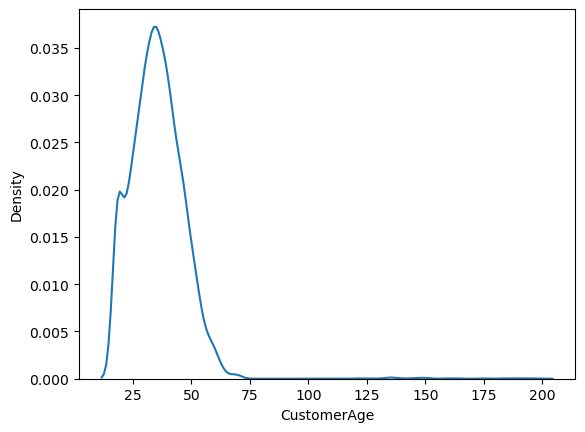

In [81]:
sns.kdeplot(data=data, x='CustomerAge')

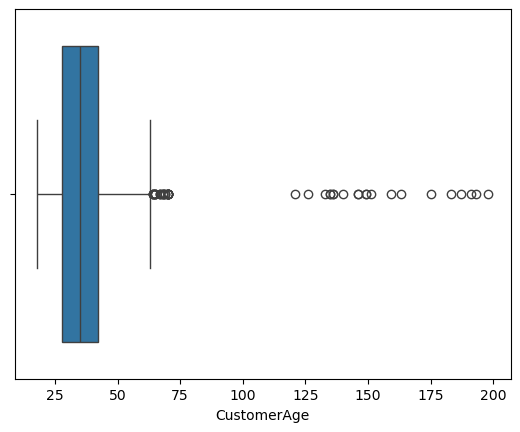

In [82]:
sns.boxplot(data=data, x='CustomerAge')
plt.show()

In [86]:
data['CustomerAge'].quantile([0.95,0.98, 0.99, 1.00])

0.95     53.0
0.98     59.0
0.99     61.0
1.00    198.0
Name: CustomerAge, dtype: float64

In [101]:
data.loc[data['CustomerAge']!=198,'CustomerAge']

0       39
1       38
3       22
4       30
5       26
        ..
8145    35
8146    32
8147    23
8148    18
8149    44
Name: CustomerAge, Length: 6671, dtype: int64

In [103]:
data.loc[data['CustomerAge']!=198,'CustomerAge'].max()

193

In [106]:
data['CustomerAge'].quantile([0.95,0.9800,0.9899, 0.99,0.9909, 1.00])

0.9500     53.0
0.9800     59.0
0.9899     61.0
0.9900     61.0
0.9909     62.0
1.0000    198.0
Name: CustomerAge, dtype: float64

In [108]:
data.loc[data['CustomerAge']<130,'CustomerAge'].max()

126

In [109]:
data.loc[data['CustomerAge']<110,'CustomerAge'].max()

70

In [110]:
data['CustomerAge']= data.loc[data['CustomerAge']<110,'CustomerAge']

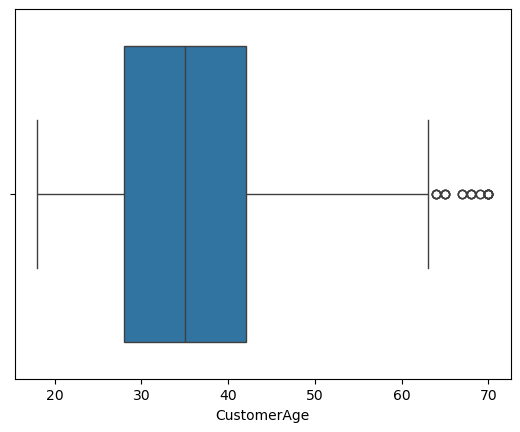

In [111]:
sns.boxplot(data=data, x='CustomerAge')
plt.show()

<Axes: xlabel='CustomerAge', ylabel='Count'>

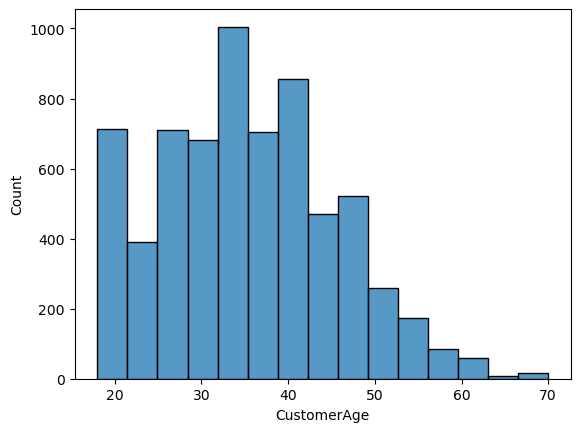

In [112]:
sns.histplot(data=data, x='CustomerAge', bins=15)

<Axes: xlabel='CustomerAge', ylabel='Density'>

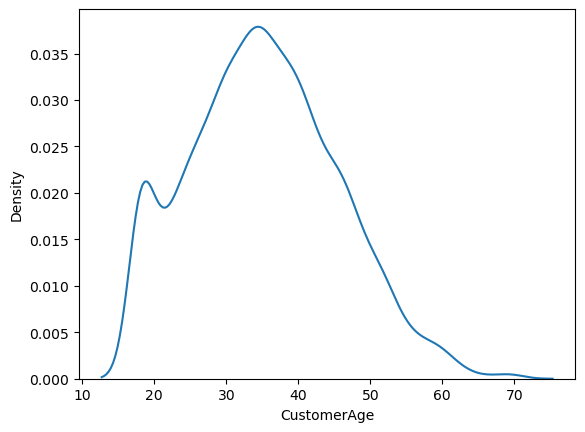

In [115]:
sns.kdeplot(data=data, x='CustomerAge')

# 

#### Quantity column

<Axes: xlabel='Quantity', ylabel='Count'>

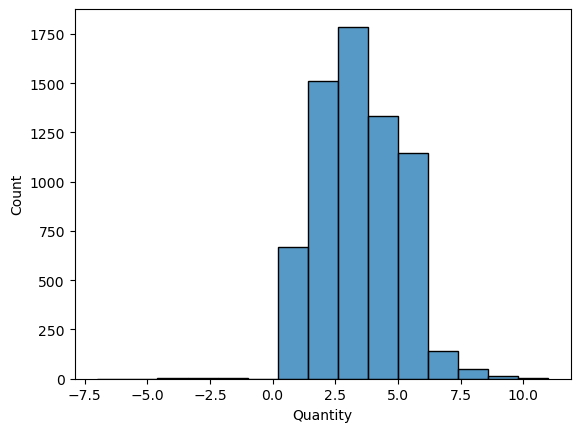

In [116]:
sns.histplot(data=data, x='Quantity', bins=15)

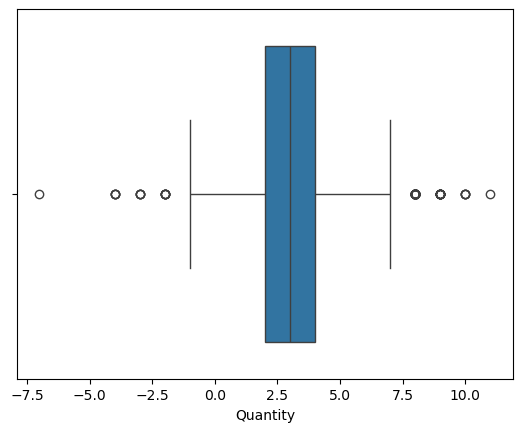

In [117]:
sns.boxplot(data=data, x='Quantity')
plt.show()

In [121]:
data['Quantity']= data.loc[data['Quantity']>=1,'Quantity']

#### Mistake: Used assignment instead of filtering, so negative values became NaN.
- (identify possible typing errors) next time

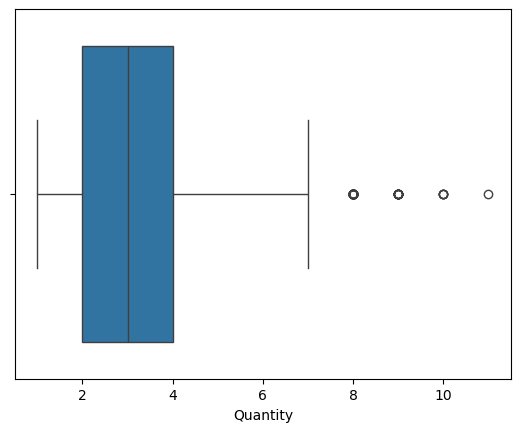

In [122]:
sns.boxplot(data=data, x='Quantity')
plt.show()

<Axes: xlabel='Quantity', ylabel='Count'>

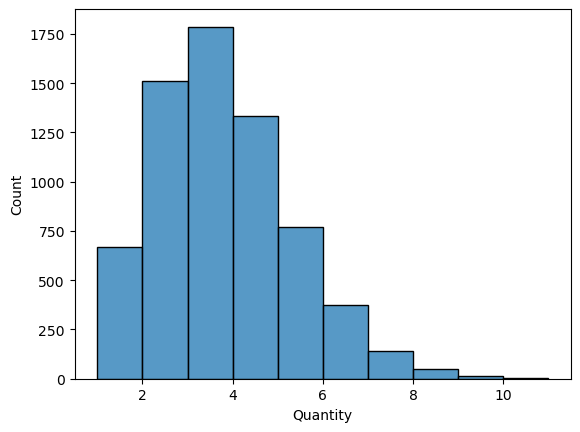

In [124]:
sns.histplot(data=data, x='Quantity', bins=10)

# 

#### UnitPrice column`

<Axes: xlabel='UnitPrice', ylabel='Count'>

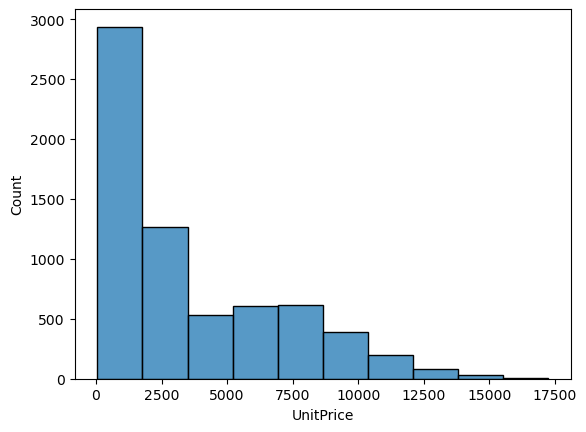

In [125]:
sns.histplot(data=data, x='UnitPrice', bins=10)

In [126]:
data[data['UnitPrice']==data['UnitPrice'].max()]

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
1868,ORD104629,2024-02-29,CUST1570,41.0,East,Odisha,Electronics,Cameras,2.0,17249.9,0.13,30014.83,8435.66,4.4,17256.57,2.0,Cash On Delivery,117.39


# 

#### Discount  column

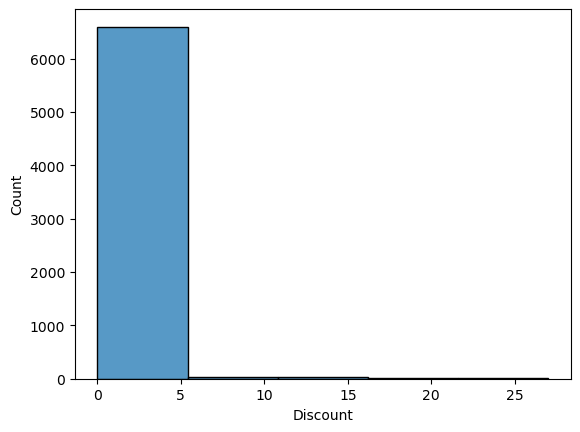

In [129]:
sns.histplot(data=data, x='Discount', bins=5)
plt.show()

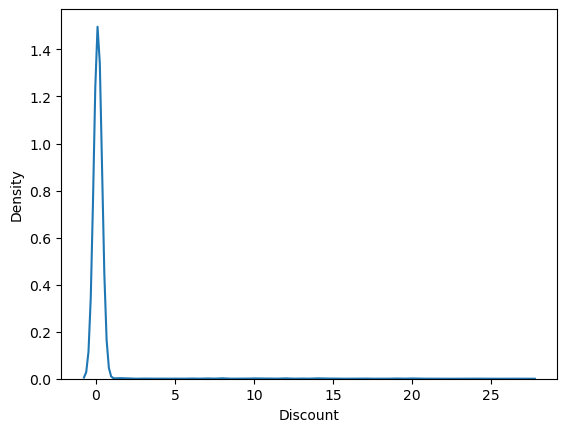

In [131]:
sns.kdeplot(data=data, x='Discount')
plt.show()

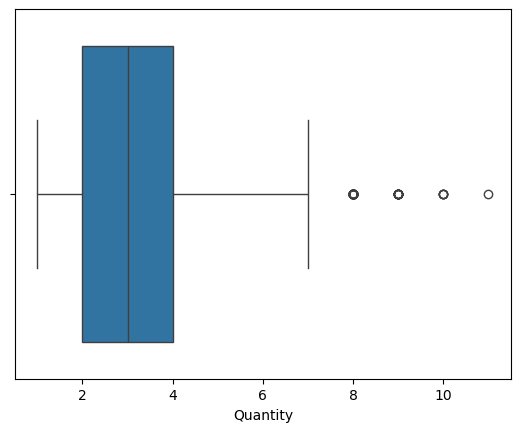

In [132]:
sns.boxplot(data=data, x='Quantity')
plt.show()

In [133]:
data[data['Discount']==data['Discount'].max()]

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
4322,ORD105815,2024-12-18,CUST2986,54.0,North,Delhi,Clothing,Footwear,2.0,701.75,27.0,1024.56,218.06,5.0,10192.26,5.0,Upi,89.97


# 

#### Sales column

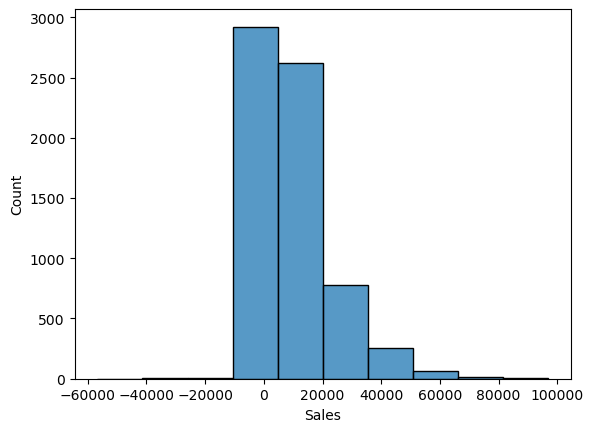

In [134]:
sns.histplot(data=data, x='Sales', bins=10)
plt.show()

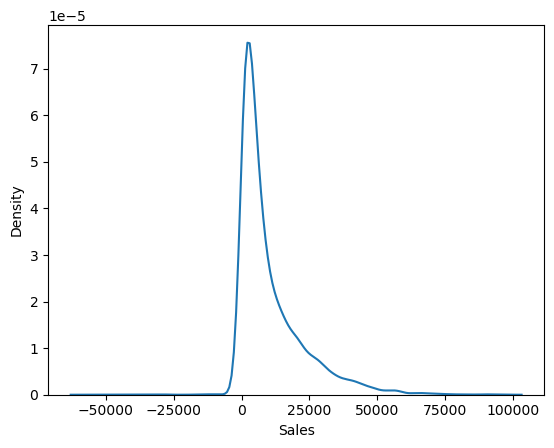

In [136]:
sns.kdeplot(data=data, x='Sales')
plt.show()

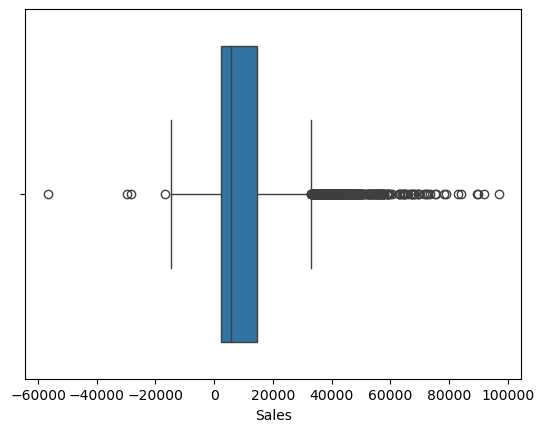

In [137]:
sns.boxplot(data=data, x='Sales')
plt.show()

In [138]:
data[data['Sales']==data['Sales'].min()]

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
4164,ORD107162,2024-03-13,CUST3945,30.0,Central,Madhya Pradesh,Electronics,Headphones,6.0,10618.86,0.11,-56704.71,8476.99,3.1,22772.97,5.0,Credit Card,149.93


#### Calculation:
  6 × 10618.86 = 63713.16  
  63713.16 × 0.89 = 56704.71  
  - Data Entry Error

In [142]:
data['CalculatedSales'] = (data['Quantity'] *data['UnitPrice'] *(1 - data['Discount']))

In [143]:
data.loc[data['Sales']<0,['Quantity','UnitPrice','Discount','Sales','CalculatedSales']]

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
81,2.0,834.93,0.16,-1402.68,1402.6824
167,3.0,2108.78,0.09,-5756.97,5756.9694
1332,1.0,1559.80,0.12,-1372.62,1372.6240
2831,1.0,3765.44,0.15,-3200.62,3200.6240
4164,6.0,10618.86,0.11,-56704.71,56704.7124
4766,3.0,473.12,0.06,-1334.20,1334.1984
4989,4.0,7688.19,0.03,-29830.18,29830.1772
5088,2.0,845.63,0.14,-1454.48,1454.4836
5144,3.0,3809.43,0.08,-10514.03,10514.0268
5543,3.0,774.94,0.29,-1650.62,1650.6222


In [146]:
data[['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].head(10)

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
0,4.0,290.93,0.15,989.16,989.1620
1,2.0,1136.09,0.17,1885.91,1885.9094
3,2.0,5060.29,0.04,9715.76,9715.7568
4,5.0,10591.15,0.17,43953.27,43953.2725
5,4.0,4739.55,0.06,17820.71,17820.7080
7,2.0,2454.28,0.14,4221.36,4221.3616
9,3.0,978.51,0.12,2583.27,2583.2664
10,8.0,7539.39,0.07,56093.06,56093.0616
11,2.0,1885.41,0.16,3167.49,3167.4888
13,2.0,5768.61,0.10,10383.50,10383.4980


In [147]:
data[['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].sample(10)

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
3985,2.0,964.45,0.10,1736.01,1736.0100
4790,1.0,331.35,0.12,291.59,291.5880
1710,3.0,7722.16,0.07,21544.83,21544.8264
6704,4.0,409.92,0.02,1606.89,1606.8864
4962,3.0,1632.32,0.18,4015.51,4015.5072
4609,5.0,7572.72,0.15,32184.06,32184.0600
6940,1.0,2315.24,0.14,1991.11,1991.1064
3104,4.0,10677.26,0.10,38438.14,38438.1360
1364,3.0,2891.77,0.07,8068.04,8068.0383
6259,4.0,1391.01,0.20,4451.23,4451.2320


In [150]:
data.loc[data['Sales']!=data['CalculatedSales'],['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].head()

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
0,4.0,290.93,0.15,989.16,989.1620
1,2.0,1136.09,0.17,1885.91,1885.9094
3,2.0,5060.29,0.04,9715.76,9715.7568
4,5.0,10591.15,0.17,43953.27,43953.2725
5,4.0,4739.55,0.06,17820.71,17820.7080


In [151]:
data['CalculatedSales'] = round(data['CalculatedSales'],2)

In [153]:
data.loc[data['Sales']!=data['CalculatedSales'],['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].head(10)

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
81,2.0,834.93,0.16,-1402.68,1402.68
83,1.0,1056.63,1.50,929.83,-528.32
95,4.0,903.21,20.00,2890.27,-68643.96
167,3.0,2108.78,0.09,-5756.97,5756.97
183,3.0,7412.74,8.00,20459.16,-155667.54
281,2.0,5028.26,21.00,7944.65,-201130.40
444,5.0,1385.12,8.00,6371.55,-48479.20
463,1.0,1460.91,8.00,1344.04,-10226.37
524,2.0,7166.83,14.00,12326.95,-186337.58
604,4.0,4463.50,11.00,15890.06,-178540.00


In [154]:
data['Discount'].unique()[:50]

array([1.5e-01, 1.7e-01, 4.0e-02, 6.0e-02, 1.4e-01, 1.2e-01, 7.0e-02,
       1.6e-01, 1.0e-01, 1.1e-01, 9.0e-02, 0.0e+00, 2.1e-01, 1.0e-02,
       2.0e-01, 2.0e-02, 3.0e-02, 1.9e-01, 5.0e-02, 1.8e-01, 3.0e-01,
       2.4e-01, 1.3e-01, 8.0e-02, 1.5e+00, 2.0e+01, 2.5e-01, 2.2e-01,
       2.9e-01, 3.4e-01, 2.3e-01, 8.0e+00, 3.3e-01, 3.1e-01, 3.6e-01,
       2.1e+01, 3.2e-01, 2.8e-01, 2.6e-01, 2.7e-01, 1.4e+01, 1.1e+01,
       5.0e+00, 3.8e-01, 1.0e+01, 1.3e+01, 7.0e+00, 6.0e+00, 1.2e+01,
       2.0e+00])

In [159]:
data['Discount'].head()

0    0.15
1    0.17
3    0.04
4    0.17
5    0.06
Name: Discount, dtype: float64

In [161]:
data.loc[data['Discount']>1,'Discount'][:10]

83      1.5
95     20.0
183     8.0
281    21.0
444     8.0
463     8.0
524    14.0
604    11.0
626     5.0
692    20.0
Name: Discount, dtype: float64

In [162]:
data.loc[data['Discount'] > 1, 'Discount'] = (data.loc[data['Discount'] > 1, 'Discount'] / 100)

In [163]:
data['CalculatedSales'] = (data['Quantity'] *data['UnitPrice'] *(1 - data['Discount']))

In [165]:
data['CalculatedSales'] = round(data['CalculatedSales'],2)

In [166]:
data.loc[data['Sales']!=data['CalculatedSales'],['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].head()

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
81,2.0,834.93,0.160,-1402.68,1402.68
83,1.0,1056.63,0.015,929.83,1040.78
167,3.0,2108.78,0.090,-5756.97,5756.97
1332,1.0,1559.80,0.120,-1372.62,1372.62
1713,NaN,2631.54,0.060,9894.59,NaN


In [167]:
data.isnull().sum()

OrderID                  0
OrderDate                0
CustomerID               0
CustomerAge             21
Region                   0
State                    0
Category                 0
SubCategory              0
Quantity                16
UnitPrice                0
Discount                 0
Sales                    0
Profit                   0
DeliveryDays             0
CustomerMonthlySpend     0
CustomerRating           0
PaymentMode              0
ShippingCost             0
CalculatedSales         16
dtype: int64

In [169]:
data = data.dropna()

In [171]:
data.loc[data['Sales']!=data['CalculatedSales'],['Quantity','UnitPrice','Discount','Sales','CalculatedSales']].head(10)

,Quantity,UnitPrice,Discount,Sales,CalculatedSales
81,2.0,834.93,0.160,-1402.68,1402.68
83,1.0,1056.63,0.015,929.83,1040.78
167,3.0,2108.78,0.090,-5756.97,5756.97
1332,1.0,1559.80,0.120,-1372.62,1372.62
2831,1.0,3765.44,0.150,-3200.62,3200.62
3697,3.0,2045.27,0.015,4970.01,6043.77
3768,5.0,5312.61,0.015,23109.85,26164.60
3968,3.0,474.61,0.015,1309.92,1402.47
4164,6.0,10618.86,0.110,-56704.71,56704.71
4766,3.0,473.12,0.060,-1334.20,1334.20


In [176]:
data.loc[:, 'Sales'] = data['CalculatedSales']

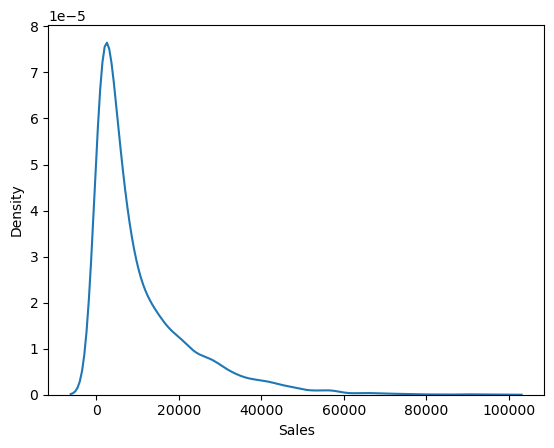

In [177]:
sns.kdeplot(data=data, x='Sales')
plt.show()

# 

#### DeliveryDays  Column

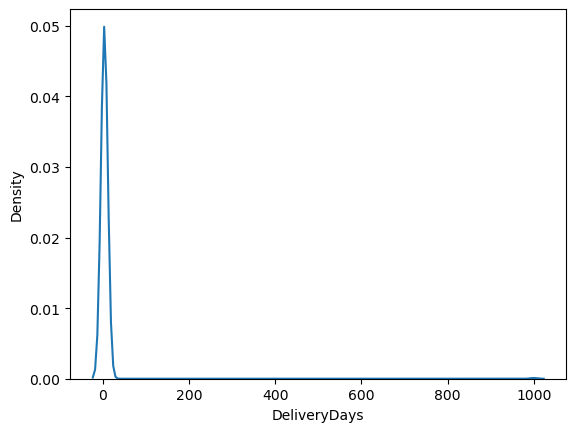

In [179]:
sns.kdeplot(data=data, x='DeliveryDays')
plt.show()

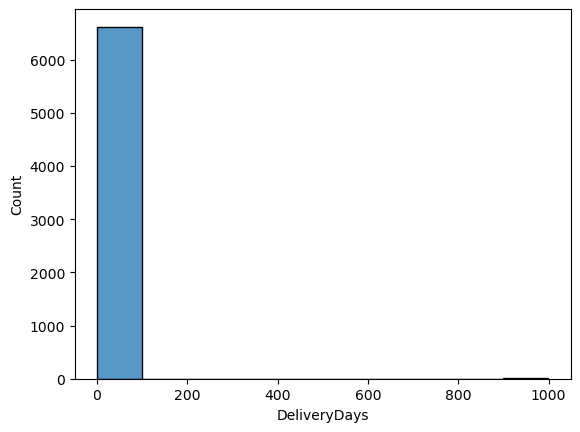

In [183]:
sns.histplot(data=data, x='DeliveryDays',bins=10)
plt.show()

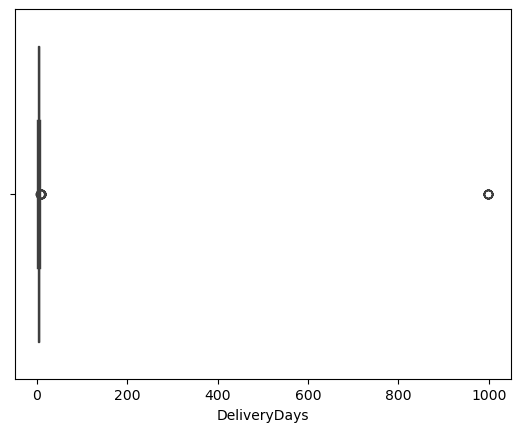

In [184]:
sns.boxplot(data=data, x='DeliveryDays')
plt.show()

In [185]:
data['DeliveryDays'].max()

999.0

In [186]:
data = data[data['DeliveryDays'] != 999]

In [187]:
data['DeliveryDays'].max()

9.9

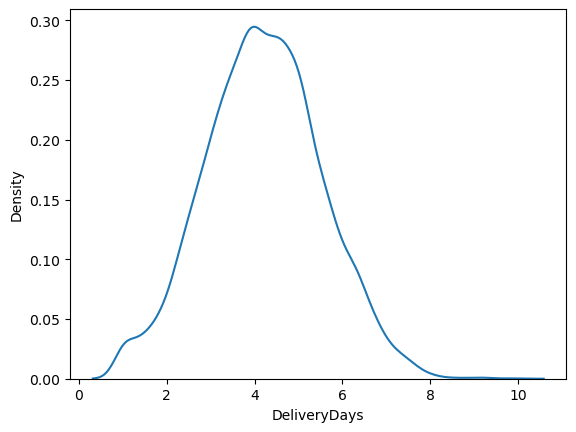

In [188]:
sns.kdeplot(data=data, x='DeliveryDays')
plt.show()

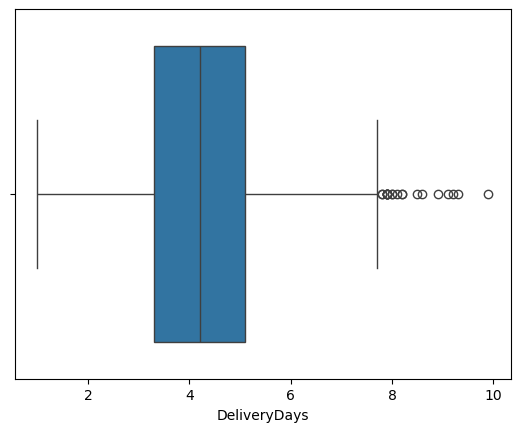

In [189]:
sns.boxplot(data=data, x='DeliveryDays')
plt.show()

In [190]:
data[data['DeliveryDays']>8]

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost,CalculatedSales
373,ORD107719,2024-08-01,CUST3342,30.0,West,Maharashtra,Electronics,Mobile Phones,3.0,6537.27,0.26,14512.74,3738.40,8.2,7952.28,4.0,Net Banking,87.38,14512.74
949,ORD107395,2024-01-03,CUST3970,27.0,South,Andhra Pradesh,Sports,Fitness Equipment,1.0,2310.27,0.06,2171.65,521.66,9.9,9664.36,3.0,Cash On Delivery,181.39,2171.65
1462,ORD103440,2024-01-20,CUST2914,42.0,East,Odisha,Electronics,Cameras,3.0,8852.69,0.14,22839.94,2850.72,9.1,13488.26,3.0,Upi,95.39,22839.94
1690,ORD102535,2024-07-16,CUST2835,35.0,South,Andhra Pradesh,Furniture,Bookcases,2.0,7393.36,0.03,14343.12,3557.51,9.2,17070.70,1.0,Net Banking,106.34,14343.12
2192,ORD103538,2023-01-19,CUST2050,28.0,Central,Madhya Pradesh,Furniture,Bookcases,5.0,5864.91,0.15,24925.87,1125.82,8.5,16588.98,4.0,Credit Card,76.65,24925.87
2431,ORD101061,2024-10-30,CUST2741,40.0,East,Bihar,Home Decor,Wall Art,3.0,1258.91,0.16,3172.45,954.71,8.2,12370.97,4.0,Credit Card,154.89,3172.45
4674,ORD105807,2024-04-24,CUST2759,34.0,Central,Chhattisgarh,Electronics,Laptops,3.0,8098.75,0.04,23324.40,6102.30,9.3,4320.22,5.0,Cash On Delivery,130.99,23324.40
4685,ORD100404,2023-07-09,CUST4012,59.0,Central,Madhya Pradesh,Furniture,Tables,2.0,5545.86,0.17,9206.13,1336.36,8.1,6171.10,4.0,Credit Card,143.30,9206.13
7037,ORD103472,2024-05-01,CUST2284,30.0,South,Karnataka,Clothing,Men Wear,3.0,1412.80,0.28,3051.65,564.04,8.6,12477.96,5.0,Net Banking,82.29,3051.65
7829,ORD100395,2024-04-15,CUST1366,36.0,Central,Madhya Pradesh,Electronics,Cameras,3.0,5508.16,0.11,14706.79,1382.82,8.9,8054.83,5.0,Credit Card,130.73,14706.79


In [192]:
data = data.drop(columns="CalculatedSales")

# 

In [193]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6622 entries, 0 to 8149
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               6622 non-null   object        
 1   OrderDate             6622 non-null   datetime64[ns]
 2   CustomerID            6622 non-null   object        
 3   CustomerAge           6622 non-null   float64       
 4   Region                6622 non-null   object        
 5   State                 6622 non-null   object        
 6   Category              6622 non-null   object        
 7   SubCategory           6622 non-null   object        
 8   Quantity              6622 non-null   float64       
 9   UnitPrice             6622 non-null   float64       
 10  Discount              6622 non-null   float64       
 11  Sales                 6622 non-null   float64       
 12  Profit                6622 non-null   float64       
 13  DeliveryDays          6

In [195]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
OrderDate,6622,2023-12-31 16:01:48.728480768,2023-01-01 00:00:00,2023-07-02 00:00:00,2024-01-02 12:00:00,2024-06-30 00:00:00,2024-12-30 00:00:00,NaN
CustomerAge,6622.0,35.217608,18.0,28.0,35.0,42.0,70.0,10.28381
Quantity,6622.0,3.310782,1.0,2.0,3.0,4.0,11.0,1.530657
UnitPrice,6622.0,3601.737989,50.0,1038.765,2106.82,6043.1925,17249.9,3369.396792
Discount,6622.0,0.124319,0.0,0.07,0.11,0.17,0.44,0.072336
Sales,6622.0,10518.850323,46.0,2248.205,5775.18,14610.5825,96890.28,12073.89924
Profit,6622.0,1880.760285,-3986.63,305.9,919.825,2429.43,19811.44,2540.739415
DeliveryDays,6622.0,4.207747,1.0,3.3,4.2,5.1,9.9,1.32221
CustomerMonthlySpend,6622.0,12508.124786,500.0,9977.2525,12512.82,15045.6475,27113.79,3730.207182
CustomerRating,6622.0,3.869828,1.0,3.0,4.0,5.0,5.0,1.080074


In [198]:
data['CustomerAge'] = data['CustomerAge'].astype('Int64')

In [207]:
data['OrderDate'] = pd.to_datetime(data['OrderDate']).dt.normalize()

In [210]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6610 entries, 0 to 8149
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               6610 non-null   object        
 1   OrderDate             6610 non-null   datetime64[ns]
 2   CustomerID            6610 non-null   object        
 3   CustomerAge           6610 non-null   Int64         
 4   Region                6610 non-null   object        
 5   State                 6610 non-null   object        
 6   Category              6610 non-null   object        
 7   SubCategory           6610 non-null   object        
 8   Quantity              6610 non-null   float64       
 9   UnitPrice             6610 non-null   float64       
 10  Discount              6610 non-null   float64       
 11  Sales                 6610 non-null   float64       
 12  Profit                6610 non-null   float64       
 13  DeliveryDays          6

In [211]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
OrderDate,6610,2023-12-31 19:47:56.732223744,2023-01-01 00:00:00,2023-07-02 00:00:00,2024-01-03 00:00:00,2024-06-30 18:00:00,2024-12-30 00:00:00,NaN
CustomerAge,6610.0,35.206354,18.0,28.0,35.0,42.0,70.0,10.287062
Quantity,6610.0,3.310136,1.0,2.0,3.0,4.0,11.0,1.529269
UnitPrice,6610.0,3597.187926,50.0,1039.55,2105.19,6019.5375,17249.9,3364.102079
Discount,6610.0,0.124354,0.0,0.07,0.11,0.17,0.44,0.072384
Sales,6610.0,10501.385124,46.0,2248.8525,5775.18,14605.9175,96890.28,12037.015082
Profit,6610.0,1878.469551,-3986.63,305.9,919.825,2427.9175,19811.44,2535.560156
DeliveryDays,6610.0,4.207882,1.0,3.3,4.2,5.1,9.9,1.322541
CustomerMonthlySpend,6610.0,12506.662234,500.0,9976.1775,12511.045,15045.6475,27113.79,3731.335765
CustomerRating,6610.0,3.869289,1.0,3.0,4.0,5.0,5.0,1.080583


In [212]:
data.isnull().sum()

OrderID                 0
OrderDate               0
CustomerID              0
CustomerAge             0
Region                  0
State                   0
Category                0
SubCategory             0
Quantity                0
UnitPrice               0
Discount                0
Sales                   0
Profit                  0
DeliveryDays            0
CustomerMonthlySpend    0
CustomerRating          0
PaymentMode             0
ShippingCost            0
dtype: int64

In [213]:
data.duplicated().sum()

np.int64(0)

In [214]:
data.to_csv("cleaned_retail_data.csv", index=False)

# 

# 